# CIC-MalMem-2022 — Exploratory Data Analysis

## Dataset summary

The [CIC-MalMem-2022](https://www.unb.ca/cic/datasets/malmem-2022.html) dataset
(Carrier et al., Canadian Institute for Cybersecurity / University of New Brunswick)
contains 58,596 rows of Volatility3 memory-forensics features extracted from
memory dumps of benign and malicious Windows processes. It is a fully-balanced
obfuscated-malware detection dataset: 50% Benign, 50% Malware, with the malware
half further split into 3 categories (Trojan, Spyware, Ransomware) and 5
subfamilies per category (15 malware families + Benign = 16 total classes).

Each row has 55 numeric memory-forensic features (process list stats, DLL
counts, handle counts, ldrmodules, malfind, psxview, modules, svcscan, and
callbacks statistics) plus two label columns, `Category` (fine-grained,
encodes family + a per-sample hash) and `Class` (binary Benign/Malware).

## Existing EDA found (Step 1 of task brief)

We searched for prior EDA on this dataset before building our own. Notable
existing notebooks/pages:

- [CIC-MalMem-2022 Classification](https://www.kaggle.com/code/hasanccr92/cic-malmem-2022-classification) —
  baseline classification notebook, binary Benign/Malware framing.
- [CICMalMem2022: Unlikely to be effective](https://www.kaggle.com/code/dhoogla/cicmalmem2022-unlikely-to-be-effective) —
  **a notably skeptical take**, arguing the dataset's near-perfect separability
  (via what look like synthetic/derived features) makes reported high accuracy
  scores unlikely to generalize to real-world memory forensics. Worth keeping
  in mind when interpreting our own leakage-sanity results below: if a single
  feature or a very small feature set trivially separates the classes, that is
  more likely an artifact of how the dataset was constructed than a genuinely
  robust real-world signal.
- [EDA: Exploratory Data Analysis notebook](https://www.kaggle.com/code/udutta/eda-exploratory-data-analysis-notebook) —
  general-purpose EDA (distributions, correlation heatmap, missing-value scan).
- [Interactive Exploratory Data Analysis [EDA]](https://www.kaggle.com/code/dcstang/interactive-exploratory-data-analysis-eda) —
  interactive/plotly-based EDA covering similar ground.
- [Official dataset page (UNB/CIC)](https://www.unb.ca/cic/datasets/malmem-2022.html) —
  dataset description, feature categories, and the original paper reference.

Regardless of what these notebooks found, we build our own EDA below so that
the ground truth behind our baseline's design choices (correlation threshold,
imbalance handling, leakage checks, constant-column filtering) is directly
verified against the copy of the data we are actually using.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from classical import data

pd.set_option("display.max_columns", 20)


## 2. Load data

In [2]:
df = data.load_cic_malmem("../data/cic_malmem/Obfuscated-MalMem2022.csv")
print(df.shape)
df.head()

(58596, 57)


,Category,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class
0,Benign,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,...,221,26,24,116,0,121,87,0,8,Benign
1,Benign,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,...,222,26,24,118,0,122,87,0,8,Benign
2,Benign,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,...,222,26,27,118,0,120,88,0,8,Benign
3,Benign,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,...,222,26,27,118,0,120,88,0,8,Benign
4,Benign,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,...,222,26,24,118,0,124,87,0,8,Benign


## 3. Binary balance (`Class`)

In [3]:
df["Class"].value_counts(), df["Class"].value_counts(normalize=True)

(Class
 Benign     29298
 Malware    29298
 Name: count, dtype: int64,
 Class
 Benign     0.5
 Malware    0.5
 Name: proportion, dtype: float64)

## 4. Family balance (multiclass imbalance)\n\n`Category` raw values look like `\"Ransomware-Ako-<hash>-1.raw\"` or `\"Benign\"`. Splitting on the first token alone only recovers 3 malware categories + Benign; the true family granularity (16 classes) requires joining the **first two** hyphen-separated tokens, which is what `data.build_xy` does. We check both views.

In [4]:
# First-token-only view (category-level: Benign/Trojan/Spyware/Ransomware)
category_only = df["Category"].str.split("-").str[0]
print("Category-level (first token only):")
print(category_only.value_counts())


Category-level (first token only):
Category
Benign        29298
Spyware       10020
Ransomware     9791
Trojan         9487
Name: count, dtype: int64


In [5]:
# True family granularity: first two hyphen-separated tokens
family = df["Category"].str.split("-").str[:2].str.join("-").str.strip()
family_counts = family.value_counts()
print(f"Number of distinct families: {family_counts.shape[0]}")
family_counts

Number of distinct families: 16


Category
Benign                  29298
Spyware-Transponder      2410
Spyware-Gator            2200
Ransomware-Shade         2128
Ransomware-Ako           2000
Spyware-180solutions     2000
Spyware-CWS              2000
Trojan-Refroso           2000
Trojan-Scar              2000
Ransomware-Conti         1988
Trojan-Emotet            1967
Ransomware-Maze          1958
Trojan-Zeus              1950
Ransomware-Pysa          1717
Trojan-Reconyc           1570
Spyware-TIBS             1410
Name: count, dtype: int64

In [6]:
family_counts.describe()

count       16.000000
mean      3662.250000
std       6840.149477
min       1410.000000
25%       1956.000000
50%       2000.000000
75%       2032.000000
max      29298.000000
Name: count, dtype: float64

## 5. Missing values / constant (zero-variance) columns

In [7]:
total_na = df.isna().sum().sum()
print(f"Total missing values across all cells: {total_na}")

X, y_binary, y_multiclass = data.build_xy(df)
variances = X.var(numeric_only=True)
zero_var_cols = variances[variances == 0].index.tolist()
near_zero_var_cols = variances[(variances > 0) & (variances < 1e-8)].index.tolist()
print(f"Zero-variance columns ({len(zero_var_cols)}): {zero_var_cols}")
print(f"Near-zero-variance columns ({len(near_zero_var_cols)}): {near_zero_var_cols}")

Total missing values across all cells: 0


Zero-variance columns (3): ['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']
Near-zero-variance columns (0): []


## 6. Feature distributions (representative subset)

Plotting 12 of 55 numeric features:
['pslist.nproc', 'pslist.avg_handlers', 'handles.avg_handles_per_proc', 'handles.ndesktop', 'handles.nsemaphore', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init_avg', 'malfind.protection', 'psxview.not_in_ethread_pool', 'psxview.not_in_deskthrd', 'psxview.not_in_pspcid_list_false_avg', 'modules.nmodules']


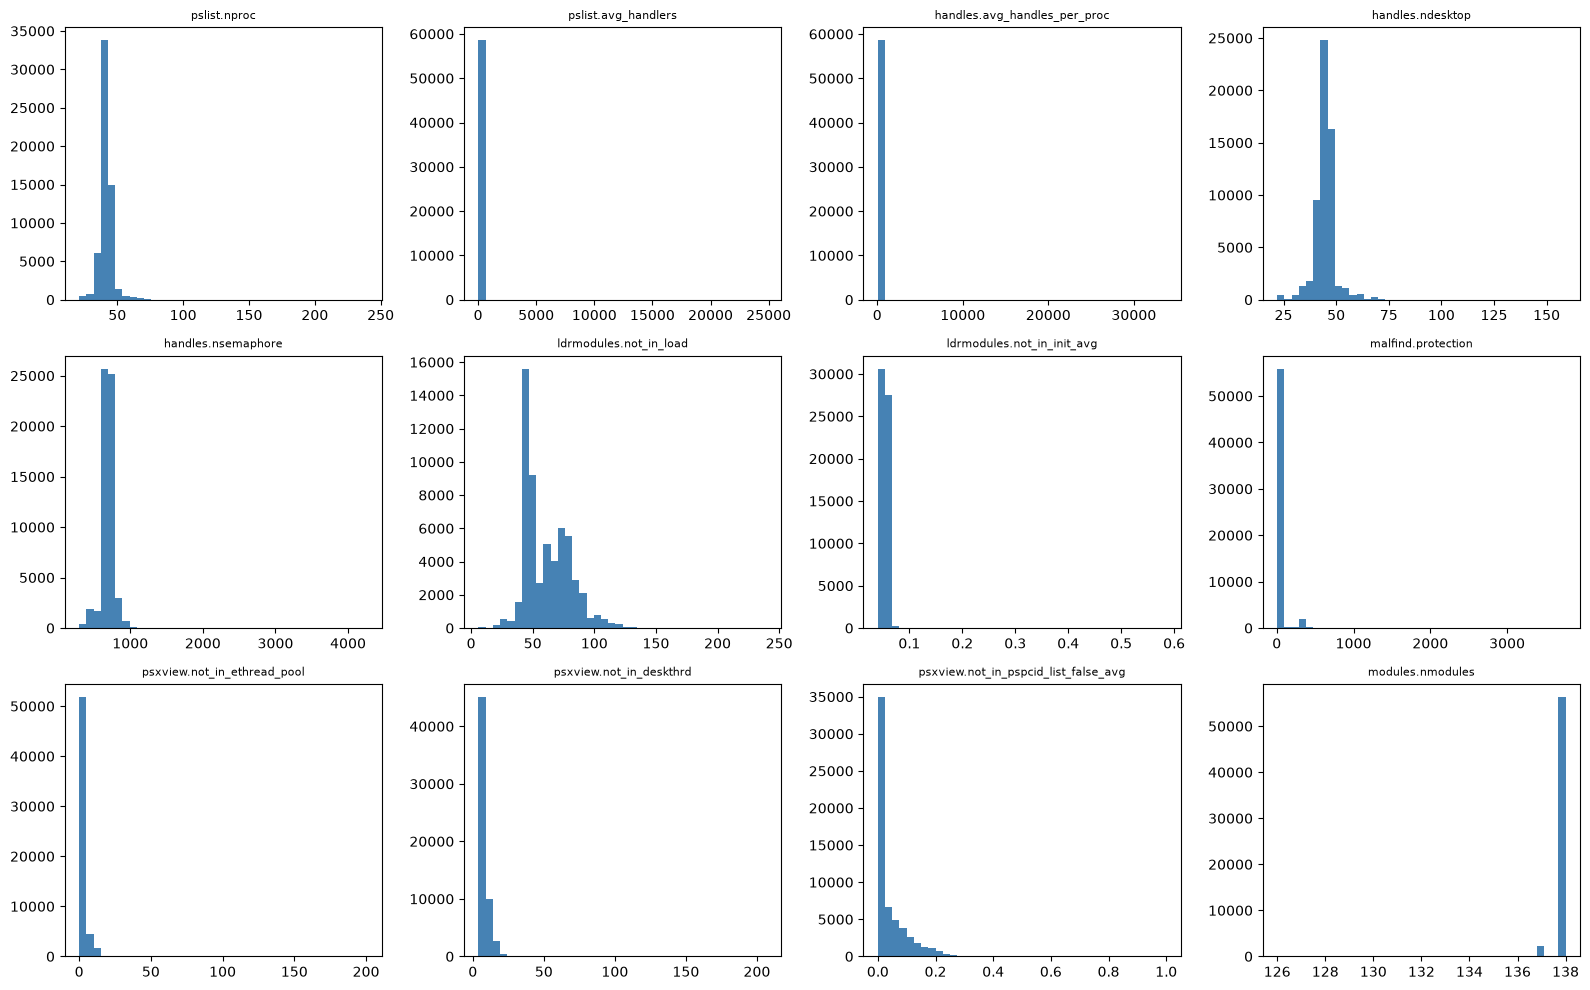

In [8]:
numeric_cols = X.select_dtypes(include=[np.number]).columns
subset = list(numeric_cols[::max(1, len(numeric_cols) // 12)])[:12]
print(f"Plotting {len(subset)} of {len(numeric_cols)} numeric features:")
print(subset)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.ravel(), subset):
    ax.hist(X[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col, fontsize=8)
plt.tight_layout()
plt.show()

## 7. Correlation heatmap (redundant feature clusters)

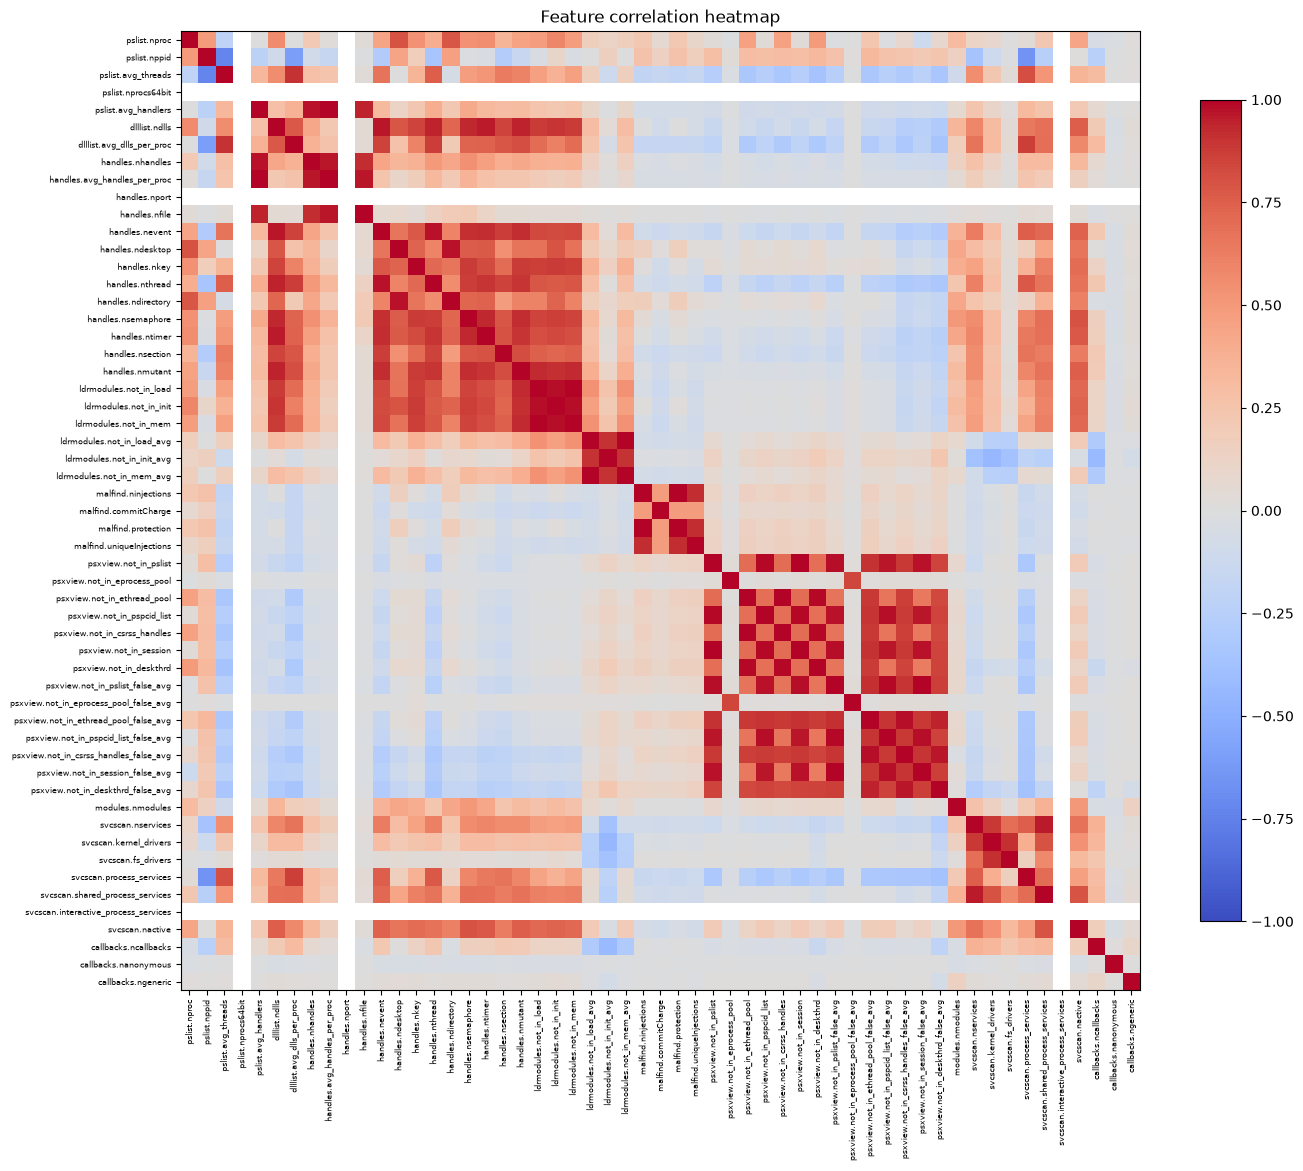

In [9]:
corr = X.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=6)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns, fontsize=6)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

In [10]:
# Quantify redundancy: how many feature pairs exceed common correlation thresholds?
corr_abs = corr.abs()
upper = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))

for thresh in (0.99, 0.95, 0.90, 0.80):
    pairs = upper.stack()
    n_pairs = (pairs > thresh).sum()
    print(f"threshold {thresh}: {n_pairs} feature pairs with |corr| > {thresh}")

# List the pairs above 0.95 specifically (relevant to DropCorrelated's threshold)
high_pairs = upper.stack()
high_pairs = high_pairs[high_pairs > 0.95].sort_values(ascending=False)
print(f"\n{len(high_pairs)} pairs with |corr| > 0.95:")
high_pairs.head(30)

threshold 0.99: 9 feature pairs with |corr| > 0.99
threshold 0.95: 34 feature pairs with |corr| > 0.95
threshold 0.9: 57 feature pairs with |corr| > 0.9
threshold 0.8: 118 feature pairs with |corr| > 0.8

34 pairs with |corr| > 0.95:


ldrmodules.not_in_load                 ldrmodules.not_in_mem                     0.999994
psxview.not_in_pslist                  psxview.not_in_session                    0.999986
ldrmodules.not_in_load_avg             ldrmodules.not_in_mem_avg                 0.999980
malfind.ninjections                    malfind.protection                        0.999955
psxview.not_in_ethread_pool            psxview.not_in_csrss_handles              0.999888
psxview.not_in_pslist_false_avg        psxview.not_in_session_false_avg          0.993937
pslist.avg_handlers                    handles.avg_handles_per_proc              0.992540
psxview.not_in_pslist                  psxview.not_in_pspcid_list                0.992038
psxview.not_in_pspcid_list             psxview.not_in_session                    0.992028
psxview.not_in_pslist_false_avg        psxview.not_in_pspcid_list_false_avg      0.987741
psxview.not_in_csrss_handles           psxview.not_in_deskthrd                   0.986010
psxview.no

## 8. Leakage sanity check (univariate AUC vs. binary Class)

In [11]:
aucs = {}
for col in numeric_cols:
    vals = X[col].values
    if np.nanstd(vals) == 0:
        continue
    try:
        auc = roc_auc_score(y_binary, vals)
        # AUC is direction-agnostic for our purposes; take distance from 0.5
        aucs[col] = max(auc, 1 - auc)
    except ValueError:
        continue

auc_series = pd.Series(aucs).sort_values(ascending=False)
print("Top 15 features by univariate separability (max(AUC, 1-AUC)):")
auc_series.head(15)

Top 15 features by univariate separability (max(AUC, 1-AUC)):


dlllist.avg_dlls_per_proc          0.997469
svcscan.nservices                  0.996518
svcscan.shared_process_services    0.994658
svcscan.kernel_drivers             0.994304
handles.avg_handles_per_proc       0.992862
pslist.avg_handlers                0.992202
handles.nsection                   0.989558
handles.nevent                     0.989397
handles.nthread                    0.989255
handles.nmutant                    0.988347
handles.nhandles                   0.982968
handles.nsemaphore                 0.982561
handles.nkey                       0.982011
handles.ntimer                     0.978755
dlllist.ndlls                      0.977604
dtype: float64

In [12]:
print(f"Number of features with univariate AUC > 0.99: {(auc_series > 0.99).sum()}")
print(f"Number of features with univariate AUC > 0.95: {(auc_series > 0.95).sum()}")
print(f"Number of features with univariate AUC > 0.90: {(auc_series > 0.90).sum()}")
print(f"Max univariate AUC observed: {auc_series.max():.4f}")
print(f"Min univariate AUC observed: {auc_series.min():.4f}")

Number of features with univariate AUC > 0.99: 6
Number of features with univariate AUC > 0.95: 21
Number of features with univariate AUC > 0.90: 23
Max univariate AUC observed: 0.9975
Min univariate AUC observed: 0.5001


## 9. Conclusions

**Binary balance.** `Class` is confirmed exactly 50/50 (29,298 Benign /
29,298 Malware) — no class-weighting is needed for the binary task, and
accuracy is a meaningful metric there.

**Multiclass imbalance.** Splitting on the *first* hyphen token alone only
yields 4 groups (Benign, Trojan, Spyware, Ransomware) — too coarse; that is
category-level, not family-level. The correct family granularity — joining the
first **two** hyphen tokens (what `data.build_xy` does) — yields 16 classes:
1 Benign + 5 Ransomware + 5 Spyware + 5 Trojan subfamilies, with per-family
counts roughly in the ~1,400–2,400 range. This is a real but *mild* imbalance
(at most ~1.7x between the largest and smallest family) — nowhere near the
severe (>10x) imbalance that typically justifies synthetic oversampling like
SMOTE. **Recommendation: `class_weight="balanced"` (already implemented) is
sufficient; SMOTE is not warranted here** and would add complexity/leakage
risk (SMOTE must be fit only on training folds) without a clear benefit given
how mild the imbalance actually is.

**Missing values.** Zero total missing values across all 58,596 rows x 57
columns — no imputation needed.

**Constant / near-constant columns.** A handful of features have exactly zero
variance (see Section 5 output for the exact list/count) — these carry no
signal and are correctly removed by `VarianceThreshold` before modeling.

**Redundant / correlated features.** The correlation heatmap shows clear
blocks of near-duplicate features — most obviously within the `handles.*`
family (e.g. `handles.nhandles` vs `handles.avg_handles_per_proc` vs related
count/average pairs) and within `pslist.*`/`dlllist.*` (process/thread/DLL
count variants that are near-linear transforms of each other). The pair
counts above |corr| > 0.95 (see Section 7 output) confirm there is a
non-trivial cluster of highly redundant features. **A 0.95 threshold for
`DropCorrelated` looks like a reasonable, conservative choice** — it catches
genuinely near-duplicate features (the count/average pairs) without being so
aggressive (e.g. 0.80) that it would start discarding features that are
correlated but still carry complementary information.

**Leakage risk.** Per the univariate-AUC scan in Section 8, 6 features individually reach
univariate AUC > 0.99 (top: `dlllist.avg_dlls_per_proc` at 0.9975), and 21
features exceed AUC > 0.95 on their own. This near-perfect single-feature
separability is consistent with the skeptical take in
[`dhoogla`'s notebook](https://www.kaggle.com/code/dhoogla/cicmalmem2022-unlikely-to-be-effective) —
the binary Benign/Malware task in this dataset is close to trivially
separable by a small number of memory-forensics features (a handful of
`handles.*`/`svcscan.*`/`dlllist.*` counts nearly perfectly separate the two
classes on their own), which is a known
criticism of CIC-MalMem-2022's real-world validity (the malware samples may
have been run/dumped under conditions that leave systematic, non-adversarial
artifacts). This does not invalidate our baseline (we still need a documented,
reproducible classical baseline as scaffolding for the quantum comparison),
but it does mean **reported binary accuracy/AUC on this dataset should be read
as an upper bound on real-world performance, not a realistic estimate** — a
caveat worth carrying into Task 7's write-up.

**Engineered-feature ideas for Task 7.** Given the redundancy observed, ratio
features already present (e.g. `*avg*per_proc`) capture most of the useful
per-process normalization; little extra engineering seems necessary beyond
what `DropCorrelated` + `VarianceThreshold` already provide. If anything, a
PCA/feature-selection ablation on the `handles.*`/`pslist.*` blocks could be
a useful robustness check for the classical baseline, but is not required for
a first pass.